# 19. Fairness, Robustness, and Operational Guardrails

A model can improve average predictive accuracy and still be a poor deployment choice. The trouble begins when error rates differ sharply across groups, calibration degrades after deployment, or action volume exceeds what the operations team can safely absorb. In those settings, a score is not enough. We need a policy layer with explicit guardrails.

This notebook treats fairness and robustness as operational design problems rather than as isolated metric exercises. We will train a risk model, evaluate it across groups, examine what happens after temporal distribution shift, and then search for a recommendation policy that balances utility, fairness, and operational feasibility.


## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain the difference between a fair score, a fair decision rule, and a deployable policy.
2. Compute group-level performance metrics such as positive rate, true positive rate, false positive rate, and precision.
3. Show how fairness metrics can move under deployment shift even when the model itself is unchanged.
4. Build an operational guardrail search that trades off expected utility against fairness and capacity constraints.
5. Summarize fairness and robustness findings in language that a deployment committee could actually use.


## 1. Core Mathematical Ideas

Let $s_i \in [0,1]$ denote a predicted risk score for unit $i$, and let $g_i$ denote the protected group used for evaluation. A threshold policy converts the score into an action indicator:

$$
\hat{a}_i = \mathbf{1}\{s_i \ge t_{g_i}\}.
$$

If we use one common threshold, then $t_{g_i} = t$ for everyone. If we use group-specific operational thresholds, then the decision rule changes by group even when the score model is fixed.

For a binary outcome $Y \in \{0,1\}$, common group metrics at threshold $t$ include:

$$
\text{TPR}_g(t) = P(\hat{a}=1 \mid Y=1, G=g),
$$

$$
\text{FPR}_g(t) = P(\hat{a}=1 \mid Y=0, G=g),
$$

$$
\text{PositiveRate}_g(t) = P(\hat{a}=1 \mid G=g),
$$

$$
\text{Precision}_g(t) = P(Y=1 \mid \hat{a}=1, G=g).
$$

A standard equalized-odds style summary is the pair of gaps

$$
\Delta_{\mathrm{TPR}} = |\text{TPR}_{A} - \text{TPR}_{B}|,
\qquad
\Delta_{\mathrm{FPR}} = |\text{FPR}_{A} - \text{FPR}_{B}|.
$$

For decision-making, we also care about utility. Suppose flagging case $i$ triggers a proactive intervention with cost $C$, effect size $e_i$, loss avoided if failure occurs $L_i$, and true failure probability $p_i$. Then the expected value of flagging is

$$
U_i = \hat{a}_i \left(p_i e_i L_i - C\right).
$$

Across the cohort, a natural objective is

$$
\max_{\pi} \; \frac{1}{n}\sum_{i=1}^n U_i
$$

subject to operational and fairness guardrails such as

$$
\Delta_{\mathrm{TPR}} \le \tau_1,
\qquad
\Delta_{\mathrm{FPR}} \le \tau_2,
\qquad
\text{FlaggedRate} \le \tau_3.
$$

This framing matters because fairness metrics do not all point in the same direction. Kleinberg et al. (2016) show that calibration-style and error-rate parity goals can conflict when groups differ in prevalence. Xu et al. (2022) review this broader incompatibility problem in applied medical prediction. Schrouff et al. (2022) emphasize that fairness can further deteriorate under distribution shift. Cheng et al. (2021) argue that the right fairness target is context-specific and should be tied to stakeholder priorities. Petersen et al. (2023) add an important distinction: a fair risk model and a fair downstream decision policy are not the same object.


In [1]:
# Section focus: 1. Core Mathematical Ideas.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 120)


def logistic(x):
    """Carry out the logistic step used in the 19. Fairness, Robustness, and Operational Guardrails workflow.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Intermediate result produced by the logistic calculation and reused by later cells.
    """
    return 1 / (1 + np.exp(-x))


def safe_auc(y_true, score):
    """Carry out the safe auc step used in the 19. Fairness, Robustness, and Operational Guardrails workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the safe auc calculation.
    """
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, score)


def safe_ap(y_true, score):
    """Carry out the safe ap step used in the 19. Fairness, Robustness, and Operational Guardrails workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    score : object
        Single score, risk value, or diagnostic value used by the decision rule.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the safe ap calculation.
    """
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return average_precision_score(y_true, score)


## 2. Operational Setting

We will stay in the same general decision-science world as the previous notebooks: a risk model supports proactive interventions on service cases before they turn into operational failures.

The important design choices for this notebook are:

- The model is trained on a stable historical environment.
- Deployment happens in a shifted environment.
- `protected_group` is **not** used as a model feature, so this is a direct illustration of why fairness-through-unawareness is not enough.
- We evaluate fairness, utility, and capacity together.

To keep the decision analysis stable, we evaluate policy value using the simulation's underlying risk rather than noisy one-off realized outcomes. That mirrors the logic from the previous notebook: the policy layer should be judged by expected decision quality, not by one lucky or unlucky batch.


In [2]:
# Section focus: 2. Operational Setting.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.



def simulate_guardrail_environment(n=6000, phase='train', scenario='reference', seed=0):
    """Create a simulated guardrail environment data set for the 19. Fairness, Robustness, and Operational Guardrails case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    phase : object
        The phase setting that controls the guardrail environment calculation in this notebook.
    scenario : object
        The scenario setting that controls the guardrail environment calculation in this notebook.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    protected_group = rng.choice(['Group A', 'Group B'], size=n, p=[0.62, 0.38])
    seller_tier = np.empty(n, dtype=object)
    region = np.empty(n, dtype=object)
    channel = np.empty(n, dtype=object)
    tenure_months = np.zeros(n)
    proxy_score = np.zeros(n)

    for i, group in enumerate(protected_group):
        if group == 'Group A':
            seller_tier[i] = rng.choice(['SMB', 'Mid-Market', 'Enterprise'], p=[0.45, 0.35, 0.20])
            region[i] = rng.choice(['North America', 'Europe', 'APAC'], p=[0.50, 0.28, 0.22])
            channel[i] = rng.choice(['Email', 'Chat', 'Phone'], p=[0.42, 0.38, 0.20])
            tenure_months[i] = np.clip(rng.normal(18, 9), 1, 60)
            proxy_score[i] = np.clip(rng.normal(0.42, 0.15), 0, 1)
        else:
            seller_tier[i] = rng.choice(['SMB', 'Mid-Market', 'Enterprise'], p=[0.52, 0.33, 0.15])
            region[i] = rng.choice(['North America', 'Europe', 'APAC'], p=[0.28, 0.22, 0.50])
            channel[i] = rng.choice(['Email', 'Chat', 'Phone'], p=[0.55, 0.25, 0.20])
            tenure_months[i] = np.clip(rng.normal(14, 8), 1, 60)
            proxy_score[i] = np.clip(rng.normal(0.55, 0.17), 0, 1)

    high_touch = (channel == 'Phone').astype(float)
    enterprise = (seller_tier == 'Enterprise').astype(float)
    mid_market = (seller_tier == 'Mid-Market').astype(float)
    apac = (region == 'APAC').astype(float)
    group_b = (protected_group == 'Group B').astype(float)
    short_tenure = (tenure_months < 10).astype(float)

    prior_load = np.clip(
        rng.normal(
            1.1
            + 0.55 * proxy_score
            + 0.35 * group_b
            + 0.30 * high_touch
            + 0.18 * apac
            + 0.12 * short_tenure,
            0.55,
        ),
        0.05,
        None,
    )
    backlog_ratio = np.clip(
        rng.normal(
            0.9
            + 0.50 * proxy_score
            + 0.20 * mid_market
            + 0.30 * enterprise
            + 0.18 * high_touch
            + 0.12 * group_b,
            0.45,
        ),
        0.05,
        None,
    )
    prior_failures = rng.poisson(np.clip(0.2 + 0.65 * proxy_score + 0.25 * group_b + 0.20 * high_touch, 0.05, 3.0))

    scenario_shifts = {
        'reference': {'intercept': 0.20, 'group_b': 0.50, 'load': 0.18, 'proxy': 0.00},
        'mild_shift': {'intercept': 0.08, 'group_b': 0.25, 'load': 0.10, 'proxy': 0.00},
        'group_b_prevalence': {'intercept': 0.12, 'group_b': 0.80, 'load': 0.12, 'proxy': 0.00},
        'workload_surge': {'intercept': 0.22, 'group_b': 0.45, 'load': 0.35, 'proxy': 0.04},
        'proxy_breakdown': {'intercept': 0.15, 'group_b': 0.55, 'load': 0.12, 'proxy': -0.45},
    }
    shift = scenario_shifts[scenario]
    deploy = 1.0 if phase == 'deploy' else 0.0

    latent_logit = (
        -4.3
        + 0.45 * mid_market
        + 0.90 * enterprise
        + 0.45 * high_touch
        + 0.20 * apac
        + 0.55 * prior_load
        + 0.75 * backlog_ratio
        + 0.28 * short_tenure
        + 0.24 * prior_failures
        + 0.40 * proxy_score
        + 0.10 * group_b
        + deploy
        * (
            shift['intercept']
            + shift['group_b'] * group_b
            + shift['load'] * prior_load
            + shift['proxy'] * proxy_score * group_b
        )
    )

    true_risk = logistic(latent_logit)
    failure = rng.binomial(1, true_risk)

    df = pd.DataFrame(
        {
            'protected_group': protected_group,
            'seller_tier': seller_tier,
            'region': region,
            'channel': channel,
            'tenure_months': tenure_months,
            'prior_load': prior_load,
            'backlog_ratio': backlog_ratio,
            'proxy_score': proxy_score,
            'prior_failures': prior_failures,
            'true_risk': true_risk,
            'failure': failure,
            'phase': phase,
            'scenario': scenario,
        }
    )
    return df


train_df = simulate_guardrail_environment(n=9000, phase='train', scenario='reference', seed=1)
reference_deploy_df = simulate_guardrail_environment(n=5000, phase='deploy', scenario='reference', seed=2)

feature_cols = [
    'seller_tier',
    'region',
    'channel',
    'tenure_months',
    'prior_load',
    'backlog_ratio',
    'proxy_score',
    'prior_failures',
]

categorical_features = ['seller_tier', 'region', 'channel']
numeric_features = [col for col in feature_cols if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ]
            ),
            categorical_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]
            ),
            numeric_features,
        ),
    ]
)

risk_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(C=0.8, max_iter=2000)),
    ]
)

risk_model.fit(train_df[feature_cols], train_df['failure'])


def attach_scores_and_value(df, model):
    """Carry out the attach scores and value step used in the 19. Fairness, Robustness, and Operational Guardrails workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    model : object
        Fitted model or model specification used by this step.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the attach scores and value calculation.
    """
    enriched = df.copy()
    enriched['score'] = model.predict_proba(enriched[feature_cols])[:, 1]

    loss_map = {'SMB': 220.0, 'Mid-Market': 520.0, 'Enterprise': 1100.0}
    enriched['loss_if_failure'] = enriched['seller_tier'].map(loss_map)
    enriched['intervention_effect'] = (
        0.22
        + 0.08 * (enriched['channel'] == 'Phone')
        + 0.05 * (enriched['backlog_ratio'] > 1.6)
        + 0.04 * (enriched['seller_tier'] == 'Enterprise')
    ).clip(0.16, 0.52)
    enriched['intervention_cost'] = 60.0
    enriched['ev_if_flagged'] = (
        enriched['true_risk'] * enriched['intervention_effect'] * enriched['loss_if_failure']
        - enriched['intervention_cost']
    )
    return enriched


train_scored = attach_scores_and_value(train_df, risk_model)
reference_scored = attach_scores_and_value(reference_deploy_df, risk_model)

cohort_overview = pd.DataFrame(
    [
        {
            'environment': 'Stable train',
            'rows': len(train_scored),
            'observed_failure_rate': train_scored['failure'].mean(),
            'average_score': train_scored['score'].mean(),
            'roc_auc': safe_auc(train_scored['failure'], train_scored['score']),
            'average_precision': safe_ap(train_scored['failure'], train_scored['score']),
            'brier_score': brier_score_loss(train_scored['failure'], train_scored['score']),
        },
        {
            'environment': 'Shifted deploy',
            'rows': len(reference_scored),
            'observed_failure_rate': reference_scored['failure'].mean(),
            'average_score': reference_scored['score'].mean(),
            'roc_auc': safe_auc(reference_scored['failure'], reference_scored['score']),
            'average_precision': safe_ap(reference_scored['failure'], reference_scored['score']),
            'brier_score': brier_score_loss(reference_scored['failure'], reference_scored['score']),
        },
    ]
)

cohort_overview


,environment,rows,observed_failure_rate,average_score,roc_auc,average_precision,brier_score
0,Stable train,9000,0.215444,0.215459,0.725438,0.425775,0.149461
1,Shifted deploy,5000,0.338200,0.213505,0.746406,0.606439,0.204420


Operational Setting gives a checkpoint for the decision workflow. Ask which pattern would change the next modeling or governance choice.


,environment,protected_group,observed_failure_rate,average_score,mean_calibration_gap
0,Stable train,Group A,0.169495,0.174639,-0.005145
1,Stable train,Group B,0.289017,0.280818,0.008199
2,Shifted deploy,Group A,0.254806,0.176157,0.078649
3,Shifted deploy,Group B,0.470741,0.272862,0.197878


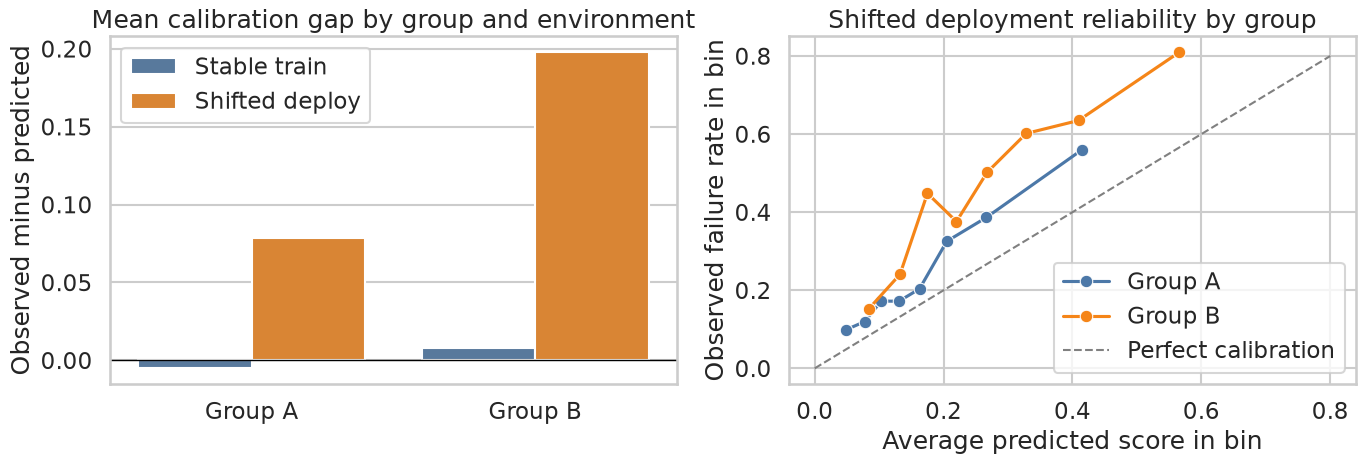

In [3]:
# Section focus: 2. Operational Setting.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.



def calibration_summary(df, environment_name):
    """Carry out the calibration summary step used in the 19. Fairness, Robustness, and Operational Guardrails workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    environment_name : object
        The environment name setting that controls the calibration summary calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for group, sub in df.groupby('protected_group'):
        rows.append(
            {
                'environment': environment_name,
                'protected_group': group,
                'observed_failure_rate': sub['failure'].mean(),
                'average_score': sub['score'].mean(),
                'mean_calibration_gap': sub['failure'].mean() - sub['score'].mean(),
            }
        )
    return pd.DataFrame(rows)


def grouped_reliability(df, n_bins=8):
    """Carry out the grouped reliability step used in the 19. Fairness, Robustness, and Operational Guardrails workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    n_bins : object
        Count or size setting for the grouped reliability calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the grouped reliability calculation and reused by later cells.
    """
    records = []
    for group, sub in df.groupby('protected_group'):
        temp = sub[['score', 'failure']].copy()
        temp['bin'] = pd.qcut(temp['score'], q=min(n_bins, temp['score'].nunique()), duplicates='drop')
        grouped = (
            temp.groupby('bin', observed=True)
            .agg(avg_score=('score', 'mean'), observed_rate=('failure', 'mean'), count=('failure', 'size'))
            .reset_index(drop=True)
        )
        grouped['protected_group'] = group
        records.append(grouped)
    return pd.concat(records, ignore_index=True)


group_shift_table = pd.concat(
    [
        calibration_summary(train_scored, 'Stable train'),
        calibration_summary(reference_scored, 'Shifted deploy'),
    ],
    ignore_index=True,
)

display(group_shift_table)

reliability_df = grouped_reliability(reference_scored, n_bins=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=group_shift_table,
    x='protected_group',
    y='mean_calibration_gap',
    hue='environment',
    palette=['#4c78a8', '#f58518'],
    ax=axes[0],
)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Mean calibration gap by group and environment')
axes[0].set_xlabel('')
axes[0].set_ylabel('Observed minus predicted')
axes[0].legend(title='')

sns.lineplot(
    data=reliability_df,
    x='avg_score',
    y='observed_rate',
    hue='protected_group',
    marker='o',
    palette=['#4c78a8', '#f58518'],
    ax=axes[1],
)
reference_line = np.linspace(0, 0.8, 100)
axes[1].plot(reference_line, reference_line, linestyle='--', color='gray', linewidth=1.5, label='Perfect calibration')
axes[1].set_title('Shifted deployment reliability by group')
axes[1].set_xlabel('Average predicted score in bin')
axes[1].set_ylabel('Observed failure rate in bin')
axes[1].legend(title='')

plt.tight_layout()
plt.show()


The deployment picture is already telling us something important.

- Aggregate discrimination remains decent, but deployment calibration deteriorates.
- The model underpredicts failure rates after shift for both groups.
- The underprediction is noticeably worse for `Group B`, which means any fixed threshold inherited from training will interact with the groups differently.

This is exactly the setting where fairness and robustness become inseparable. A policy can inherit disparities not because the threshold code changed, but because the environment did.


## 3. Fairness at a Single Operational Threshold

We start with a deliberately simple policy: flag any case with predicted risk at or above `0.20` for proactive review. This is a realistic baseline because many teams inherit a single threshold from a validation report and then treat it as a deployment rule.

The question is not whether the threshold is easy to explain. The question is whether it remains acceptable once we inspect who gets flagged, how often mistakes occur in each group, and what value the interventions are expected to generate.


In [4]:
# Section focus: 3. Fairness at a Single Operational Threshold.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.



def policy_metrics(df, thresholds, group_col='protected_group'):
    """Carry out the policy metrics step used in the 19. Fairness, Robustness, and Operational Guardrails workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    thresholds : object
        Candidate decision cutoffs compared by the evaluation step.
    group_col : object
        Column name identifying the group or segment used for comparison.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    if isinstance(thresholds, (int, float, np.floating)):
        threshold_map = {group: float(thresholds) for group in sorted(df[group_col].unique())}
    else:
        threshold_map = dict(thresholds)

    eval_df = df.copy()
    eval_df['threshold'] = eval_df[group_col].map(threshold_map)
    eval_df['flag'] = (eval_df['score'] >= eval_df['threshold']).astype(int)
    eval_df['realized_utility'] = eval_df['flag'] * eval_df['ev_if_flagged']

    rows = []
    for group, sub in eval_df.groupby(group_col):
        tp = ((sub['flag'] == 1) & (sub['failure'] == 1)).sum()
        fp = ((sub['flag'] == 1) & (sub['failure'] == 0)).sum()
        fn = ((sub['flag'] == 0) & (sub['failure'] == 1)).sum()
        tn = ((sub['flag'] == 0) & (sub['failure'] == 0)).sum()

        tpr = tp / (tp + fn) if (tp + fn) else np.nan
        fpr = fp / (fp + tn) if (fp + tn) else np.nan
        precision = tp / (tp + fp) if (tp + fp) else np.nan

        rows.append(
            {
                'protected_group': group,
                'threshold': sub['threshold'].iloc[0],
                'positive_rate': sub['flag'].mean(),
                'true_positive_rate': tpr,
                'false_positive_rate': fpr,
                'precision': precision,
                'utility_per_1000': 1000 * sub['realized_utility'].sum() / len(sub),
                'cases': len(sub),
            }
        )

    group_table = pd.DataFrame(rows)
    summary = {
        'overall_flagged_rate': eval_df['flag'].mean(),
        'overall_utility_per_1000': 1000 * eval_df['realized_utility'].sum() / len(eval_df),
        'tpr_gap': abs(group_table['true_positive_rate'].iloc[0] - group_table['true_positive_rate'].iloc[1]),
        'fpr_gap': abs(group_table['false_positive_rate'].iloc[0] - group_table['false_positive_rate'].iloc[1]),
        'positive_rate_gap': abs(group_table['positive_rate'].iloc[0] - group_table['positive_rate'].iloc[1]),
        'worst_group_precision': group_table['precision'].min(),
    }
    return eval_df, group_table, summary


naive_threshold = 0.20
naive_eval_df, naive_group_table, naive_summary = policy_metrics(reference_scored, naive_threshold)

display(naive_group_table)
pd.DataFrame([naive_summary])


,protected_group,threshold,positive_rate,true_positive_rate,false_positive_rate,precision,utility_per_1000,cases
0,Group A,0.2,0.322906,0.570332,0.238303,0.450050,11170.132936,3069
1,Group B,0.2,0.616779,0.767877,0.482387,0.586062,24609.459249,1931


,overall_flagged_rate,overall_utility_per_1000,tpr_gap,fpr_gap,positive_rate_gap,worst_group_precision
0,0.4364,16360.400758,0.197544,0.244084,0.293872,0.45005


The model comparison now needs to be read through the decision it supports. The useful reading is which metric would change the action in Fairness at a Single Operational Threshold. The right metric depends on which mistake is operationally expensive.


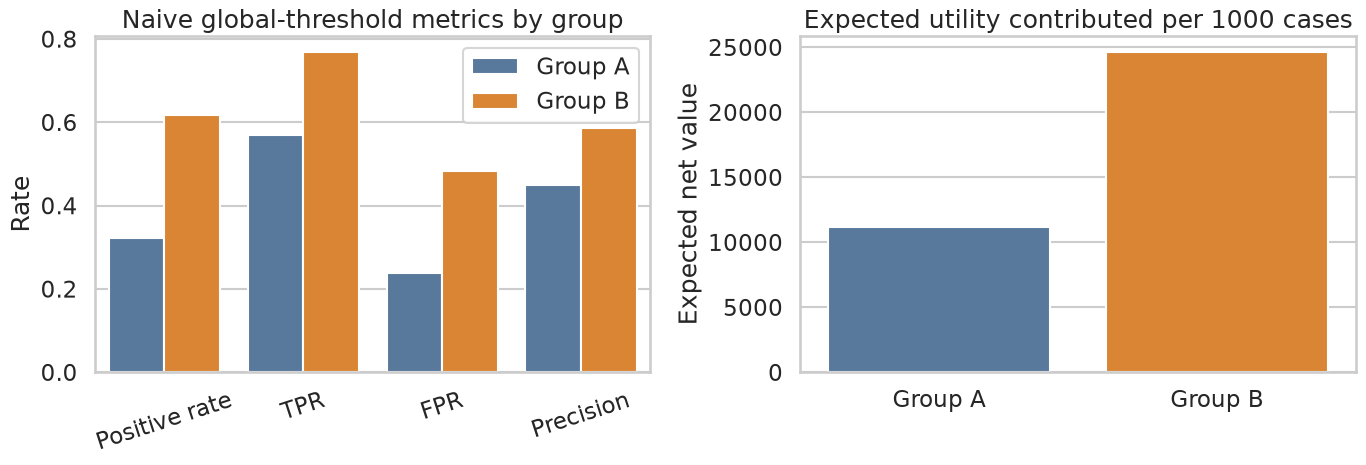

In [5]:
# Section focus: 3. Fairness at a Single Operational Threshold.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


plot_group_metrics = naive_group_table.melt(
    id_vars='protected_group',
    value_vars=['positive_rate', 'true_positive_rate', 'false_positive_rate', 'precision'],
    var_name='metric',
    value_name='value',
)
plot_group_metrics['metric'] = plot_group_metrics['metric'].map(
    {
        'positive_rate': 'Positive rate',
        'true_positive_rate': 'TPR',
        'false_positive_rate': 'FPR',
        'precision': 'Precision',
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=plot_group_metrics,
    x='metric',
    y='value',
    hue='protected_group',
    palette=['#4c78a8', '#f58518'],
    ax=axes[0],
)
axes[0].set_title('Naive global-threshold metrics by group')
axes[0].set_xlabel('')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=18)
axes[0].legend(title='')

sns.barplot(
    data=naive_group_table,
    x='protected_group',
    y='utility_per_1000',
    palette=['#4c78a8', '#f58518'],
    ax=axes[1],
)
axes[1].set_title('Expected utility contributed per 1000 cases')
axes[1].set_xlabel('')
axes[1].set_ylabel('Expected net value')

plt.tight_layout()
plt.show()


The baseline policy is useful, but it is not neutral.

Even though `protected_group` never entered the feature matrix directly, the deployment policy still creates materially different action rates and error patterns by group. This is the standard lesson of fairness-through-unawareness: excluding the protected variable is not the same as equalizing downstream consequences.


## 4. Threshold Sweeps and Trade-Offs

Next we vary a **single global threshold** and track three things at once:

1. expected utility,
2. fairness gaps,
3. operational workload.

This is the most honest way to think about a threshold. It is not a scalar picked from aesthetic preference. It is a policy knob that moves multiple objectives at once.


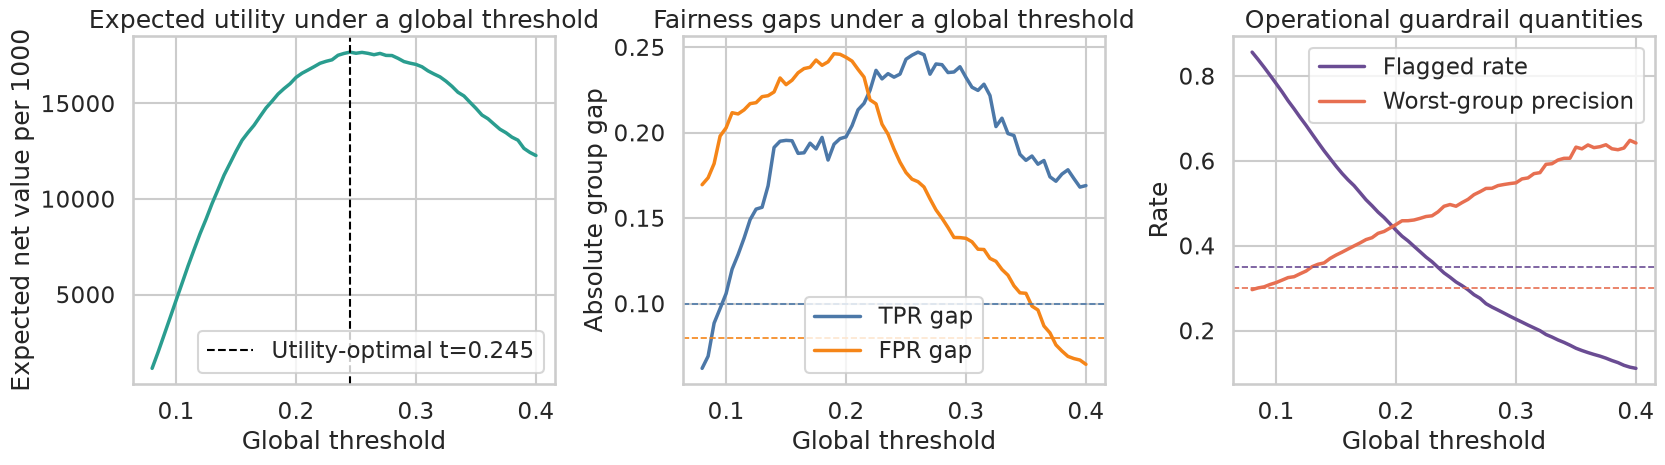

No single global threshold satisfies the full guardrail set in this run.


In [6]:
# Section focus: 4. Threshold Sweeps and Trade-Offs.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

threshold_grid = np.linspace(0.08, 0.40, 65)
global_sweep_rows = []

for threshold in threshold_grid:
    _, group_table, summary = policy_metrics(reference_scored, threshold)
    global_sweep_rows.append(
        {
            'threshold': threshold,
            'utility_per_1000': summary['overall_utility_per_1000'],
            'flagged_rate': summary['overall_flagged_rate'],
            'tpr_gap': summary['tpr_gap'],
            'fpr_gap': summary['fpr_gap'],
            'positive_rate_gap': summary['positive_rate_gap'],
            'worst_group_precision': summary['worst_group_precision'],
        }
    )

global_sweep = pd.DataFrame(global_sweep_rows)
global_sweep['feasible_guardrails'] = (
    (global_sweep['flagged_rate'] <= 0.35)
    & (global_sweep['tpr_gap'] <= 0.10)
    & (global_sweep['fpr_gap'] <= 0.08)
    & (global_sweep['worst_group_precision'] >= 0.30)
)

utility_opt_idx = global_sweep['utility_per_1000'].idxmax()
utility_opt_threshold = global_sweep.loc[utility_opt_idx, 'threshold']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.lineplot(data=global_sweep, x='threshold', y='utility_per_1000', color='#2a9d8f', linewidth=2.5, ax=axes[0])
axes[0].axvline(utility_opt_threshold, color='black', linestyle='--', linewidth=1.5, label=f'Utility-optimal t={utility_opt_threshold:.3f}')
axes[0].set_title('Expected utility under a global threshold')
axes[0].set_ylabel('Expected net value per 1000')
axes[0].legend()

sns.lineplot(data=global_sweep, x='threshold', y='tpr_gap', label='TPR gap', color='#4c78a8', linewidth=2.5, ax=axes[1])
sns.lineplot(data=global_sweep, x='threshold', y='fpr_gap', label='FPR gap', color='#f58518', linewidth=2.5, ax=axes[1])
axes[1].axhline(0.10, color='#4c78a8', linestyle='--', linewidth=1.2)
axes[1].axhline(0.08, color='#f58518', linestyle='--', linewidth=1.2)
axes[1].set_title('Fairness gaps under a global threshold')
axes[1].set_ylabel('Absolute group gap')

sns.lineplot(data=global_sweep, x='threshold', y='flagged_rate', label='Flagged rate', color='#6a4c93', linewidth=2.5, ax=axes[2])
sns.lineplot(data=global_sweep, x='threshold', y='worst_group_precision', label='Worst-group precision', color='#e76f51', linewidth=2.5, ax=axes[2])
axes[2].axhline(0.35, color='#6a4c93', linestyle='--', linewidth=1.2)
axes[2].axhline(0.30, color='#e76f51', linestyle='--', linewidth=1.2)
axes[2].set_title('Operational guardrail quantities')
axes[2].set_ylabel('Rate')

for ax in axes:
    ax.set_xlabel('Global threshold')

plt.tight_layout()
plt.show()

feasible_global = global_sweep.loc[global_sweep['feasible_guardrails']].copy()
if feasible_global.empty:
    print('No single global threshold satisfies the full guardrail set in this run.')
else:
    display(feasible_global.head())

In this run, the single-threshold sweep produces a strong but uncomfortable result:

- there is a clear utility-optimal global threshold,
- but the fairness gaps at that point are large,
- and in fact **no global threshold satisfies the full guardrail set** we imposed.

The model may still be usable, but the deployment committee should stop treating one inherited threshold as an acceptable policy without review.


## 5. Search for a Guardrail-Compliant Policy

We now search over **group-specific thresholds**. This is not presented as a universal fairness remedy. It is a policy design exercise.

The guardrails in this notebook are:

- flagged rate <= `0.35`
- TPR gap <= `0.10`
- FPR gap <= `0.08`
- worst-group precision >= `0.30`

Among threshold pairs that satisfy these constraints, we pick the one with the highest expected utility.


,policy,threshold_group_a,threshold_group_b,overall_flagged_rate,overall_utility_per_1000,tpr_gap,fpr_gap,positive_rate_gap,worst_group_precision
0,Utility-optimal global threshold,0.245,0.245,0.3258,17681.747919,0.234263,0.182703,0.268197,0.497067
1,Guardrail-compliant group thresholds,0.220,0.280,0.3252,17621.744136,0.077379,0.052850,0.129963,0.464455


,protected_group,threshold,positive_rate,true_positive_rate,false_positive_rate,precision,utility_per_1000,cases
0,Group A,0.22,0.275008,0.501279,0.197639,0.464455,11800.585827,3069
1,Group B,0.28,0.404972,0.578658,0.250489,0.672634,26873.497036,1931


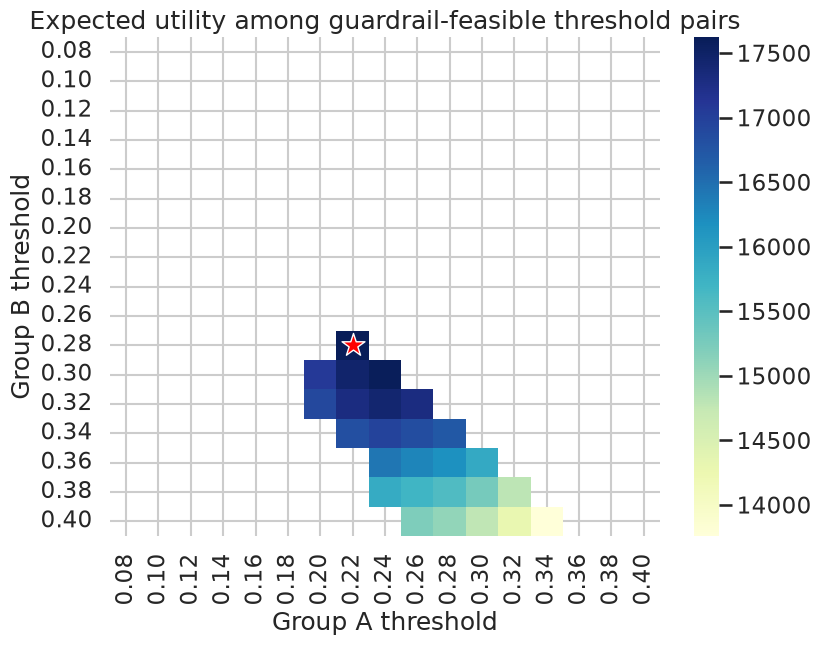

Red star: highest-utility threshold pair among the policies that satisfy the reference-environment guardrails.


In [7]:
# Section focus: 5. Search for a Guardrail-Compliant Policy.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

search_grid = np.linspace(0.08, 0.40, 17)
search_rows = []

for threshold_a in search_grid:
    for threshold_b in search_grid:
        _, group_table, summary = policy_metrics(
            reference_scored,
            {'Group A': threshold_a, 'Group B': threshold_b},
        )
        feasible = (
            (summary['overall_flagged_rate'] <= 0.35)
            and (summary['tpr_gap'] <= 0.10)
            and (summary['fpr_gap'] <= 0.08)
            and (summary['worst_group_precision'] >= 0.30)
        )
        search_rows.append(
            {
                'threshold_group_a': threshold_a,
                'threshold_group_b': threshold_b,
                'utility_per_1000': summary['overall_utility_per_1000'],
                'flagged_rate': summary['overall_flagged_rate'],
                'tpr_gap': summary['tpr_gap'],
                'fpr_gap': summary['fpr_gap'],
                'positive_rate_gap': summary['positive_rate_gap'],
                'worst_group_precision': summary['worst_group_precision'],
                'feasible_guardrails': feasible,
            }
        )

search_df = pd.DataFrame(search_rows)
feasible_df = search_df.loc[search_df['feasible_guardrails']].copy()

best_guardrail_row = feasible_df.sort_values('utility_per_1000', ascending=False).iloc[0]
best_guardrail_thresholds = {
    'Group A': best_guardrail_row['threshold_group_a'],
    'Group B': best_guardrail_row['threshold_group_b'],
}

_, utility_opt_global_table, utility_opt_global_summary = policy_metrics(reference_scored, utility_opt_threshold)
_, guardrail_table, guardrail_summary = policy_metrics(reference_scored, best_guardrail_thresholds)

comparison_table = pd.DataFrame(
    [
        {
            'policy': 'Utility-optimal global threshold',
            'threshold_group_a': utility_opt_threshold,
            'threshold_group_b': utility_opt_threshold,
            **utility_opt_global_summary,
        },
        {
            'policy': 'Guardrail-compliant group thresholds',
            'threshold_group_a': best_guardrail_row['threshold_group_a'],
            'threshold_group_b': best_guardrail_row['threshold_group_b'],
            **guardrail_summary,
        },
    ]
)

display(comparison_table)
display(guardrail_table)

heatmap_df = search_df.copy()
heatmap_df['utility_if_feasible'] = heatmap_df['utility_per_1000'].where(heatmap_df['feasible_guardrails'])
heatmap_pivot = heatmap_df.pivot(index='threshold_group_b', columns='threshold_group_a', values='utility_if_feasible')
heatmap_display = heatmap_pivot.copy()
heatmap_display.index = [f'{value:.2f}' for value in heatmap_display.index]
heatmap_display.columns = [f'{value:.2f}' for value in heatmap_display.columns]

fig, ax = plt.subplots(figsize=(8.6, 6.8))
sns.heatmap(heatmap_display, cmap='YlGnBu', ax=ax)
ax.set_title('Expected utility among guardrail-feasible threshold pairs')
ax.set_xlabel('Group A threshold')
ax.set_ylabel('Group B threshold')

col_positions = list(heatmap_pivot.columns)
row_positions = list(heatmap_pivot.index)
star_x = col_positions.index(best_guardrail_row['threshold_group_a']) + 0.5
star_y = row_positions.index(best_guardrail_row['threshold_group_b']) + 0.5
ax.scatter(star_x, star_y, marker='*', s=300, color='red', edgecolor='white', linewidth=1.0)

plt.tight_layout()
plt.show()

print('Red star: highest-utility threshold pair among the policies that satisfy the reference-environment guardrails.')

The key comparison is deliberately uncomfortable.

The utility-optimal global threshold is slightly better on pure value, but it fails the fairness guardrails badly. The guardrail-compliant threshold pair gives up very little utility while tightening the TPR and FPR gaps dramatically.

That is what guardrails are for. They are not there to maximize one metric. They are there to keep a deployment inside an acceptable operating region.


## 6. Robustness Under Deployment Scenarios

A policy that looks acceptable in one snapshot can still be fragile. To stress-test robustness, we keep the trained model fixed and evaluate three policies across several shifted deployment scenarios:

1. a naive global threshold (`0.20`),
2. the utility-optimal global threshold from the reference deployment,
3. the guardrail-compliant group-threshold policy.

The scenarios differ in the type and severity of shift. This matters because fairness claims that hold in one environment may not transfer to another (Schrouff et al., 2022).


In [8]:
# Section focus: 6. Robustness Under Deployment Scenarios.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


policy_library = {
    'Naive global 0.20': {'Group A': 0.20, 'Group B': 0.20},
    'Utility-optimal global': {'Group A': utility_opt_threshold, 'Group B': utility_opt_threshold},
    'Guardrail group thresholds': best_guardrail_thresholds,
}

scenario_specs = [
    ('mild_shift', 10),
    ('reference', 2),
    ('group_b_prevalence', 11),
    ('workload_surge', 12),
    ('proxy_breakdown', 13),
]

scenario_rows = []
for scenario_name, scenario_seed in scenario_specs:
    scenario_df = attach_scores_and_value(
        simulate_guardrail_environment(n=5000, phase='deploy', scenario=scenario_name, seed=scenario_seed),
        risk_model,
    )
    for policy_name, thresholds in policy_library.items():
        _, _, summary = policy_metrics(scenario_df, thresholds)
        scenario_rows.append(
            {
                'scenario': scenario_name,
                'policy': policy_name,
                **summary,
            }
        )

scenario_results = pd.DataFrame(scenario_rows)
scenario_results


,scenario,policy,overall_flagged_rate,overall_utility_per_1000,tpr_gap,fpr_gap,positive_rate_gap,worst_group_precision
0,mild_shift,Naive global 0.20,0.4368,8803.134892,0.253965,0.292463,0.335022,0.353846
1,mild_shift,Utility-optimal global,0.3332,11010.373240,0.286745,0.229688,0.299769,0.380058
2,mild_shift,Guardrail group thresholds,0.3318,11186.813899,0.118713,0.114108,0.172160,0.375149
3,reference,Naive global 0.20,0.4364,16360.400758,0.197544,0.244084,0.293872,0.450050
4,reference,Utility-optimal global,0.3258,17681.747919,0.234263,0.182703,0.268197,0.497067
5,reference,Guardrail group thresholds,0.3252,17621.744136,0.077379,0.052850,0.129963,0.464455
6,group_b_prevalence,Naive global 0.20,0.4452,13541.944646,0.186050,0.213123,0.285478,0.361905
7,group_b_prevalence,Utility-optimal global,0.3324,14947.359121,0.174804,0.165107,0.251409,0.412720
8,group_b_prevalence,Guardrail group thresholds,0.3310,14708.772189,0.026784,0.031601,0.114095,0.385045
9,workload_surge,Naive global 0.20,0.4484,22244.276249,0.256967,0.242824,0.318365,0.492432


The Robustness Under Deployment Scenarios result matters when it changes the next move. The useful evidence is the part that changes model selection, diagnostics, thresholds, or governance limits.


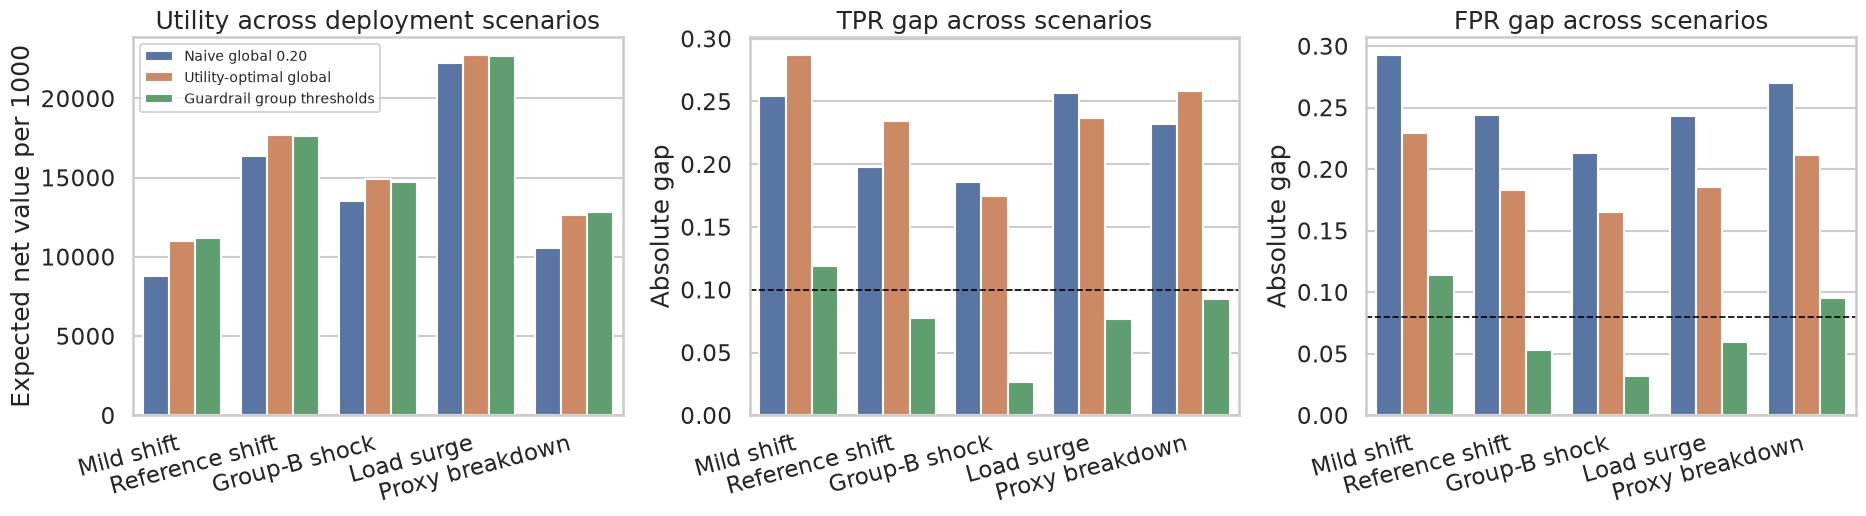

In [9]:
# Section focus: 6. Robustness Under Deployment Scenarios.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

pretty_names = {
    'mild_shift': 'Mild shift',
    'reference': 'Reference shift',
    'group_b_prevalence': 'Group-B shock',
    'workload_surge': 'Load surge',
    'proxy_breakdown': 'Proxy breakdown',
}
plot_results = scenario_results.copy()
plot_results['scenario'] = plot_results['scenario'].map(pretty_names)

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

sns.barplot(data=plot_results, x='scenario', y='overall_utility_per_1000', hue='policy', ax=axes[0])
axes[0].set_title('Utility across deployment scenarios')
axes[0].set_xlabel('')
axes[0].set_ylabel('Expected net value per 1000')
axes[0].legend(title='', fontsize=10)

sns.barplot(data=plot_results, x='scenario', y='tpr_gap', hue='policy', ax=axes[1])
axes[1].axhline(0.10, color='black', linestyle='--', linewidth=1.2)
axes[1].set_title('TPR gap across scenarios')
axes[1].set_xlabel('')
axes[1].set_ylabel('Absolute gap')
axes[1].legend_.remove()

sns.barplot(data=plot_results, x='scenario', y='fpr_gap', hue='policy', ax=axes[2])
axes[2].axhline(0.08, color='black', linestyle='--', linewidth=1.2)
axes[2].set_title('FPR gap across scenarios')
axes[2].set_xlabel('')
axes[2].set_ylabel('Absolute gap')
axes[2].legend_.remove()

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

Two robustness lessons stand out.

1. The naive and utility-optimal global thresholds remain high-disparity policies in every scenario.
2. The guardrail policy is much more stable. It preserves most of the utility while keeping TPR and FPR gaps materially smaller, even when the shift mechanism changes.

This does **not** mean the guardrail policy is universally fair. It means the policy is better aligned to the explicit deployment constraints we stated. That is a narrower and more honest claim.


## 7. Practical Deployment Memo

If this were a real model review, the recommendation would look something like this:

1. **Do not deploy a score with an inherited global threshold by default.** The model can be useful while the threshold policy remains unacceptable.
2. **Separate model evaluation from policy evaluation.** A risk score is one object; the action rule built on top of it is another.
3. **Write guardrails down before deployment.** In this notebook the guardrails were fairness gaps, minimum worst-group precision, and capacity.
4. **Retest the policy under plausible shifts.** Fairness and robustness have to be evaluated together, not in separate reports.
5. **Treat fairness targets as governance choices, not purely technical facts.** Which gap matters most depends on who bears the cost of false positives, false negatives, and exclusion from intervention.

That last point is why fairness notebooks should end with policy language, alongside diagnostic plots. A deployment decision is never made by AUROC alone.


## References

- Cheng, H.-F., Stapleton, L., Wang, R., et al. (2021). *Soliciting stakeholders' fairness notions in child maltreatment predictive systems.* [https://doi.org/10.1145/3411764.3445308](https://doi.org/10.1145/3411764.3445308)
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2016). *Inherent trade-offs in the fair determination of risk scores.* [https://doi.org/10.48550/arXiv.1609.05807](https://doi.org/10.48550/arXiv.1609.05807)
- Petersen, E., Ganz, M., Holm, S., et al. (2023). *On (assessing) the fairness of risk score models.* [https://doi.org/10.48550/arXiv.2302.08851](https://doi.org/10.48550/arXiv.2302.08851)
- Schrouff, J., Harris, N., Koyejo, O., et al. (2022). *Diagnosing failures of fairness transfer across distribution shift in real-world medical settings.* [https://doi.org/10.48550/arXiv.2202.01034](https://doi.org/10.48550/arXiv.2202.01034)
- Xu, J., Xiao, Y., Wang, H., et al. (2022). *Algorithmic fairness in computational medicine.* *EBioMedicine, 84*, 104250. [https://doi.org/10.1016/j.ebiom.2022.104250](https://doi.org/10.1016/j.ebiom.2022.104250)
